In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/raw/hypertension-adults-30-79.csv')

In [3]:
df.head()

,Entity,Code,Year,Prevalence of hypertension in adults aged 30-79
0,Afghanistan,AFG,1990,35.5
1,Afghanistan,AFG,1991,35.5
2,Afghanistan,AFG,1992,35.6
3,Afghanistan,AFG,1993,35.6
4,Afghanistan,AFG,1994,35.7


In [4]:
df.columns

Index(['Entity', 'Code', 'Year',
       'Prevalence of hypertension in adults aged 30-79'],
      dtype='object')

Since mortality data from WHO Global Health Estimates are available from 2000 onward, all WHO-based time series were restricted to the common period 2000–2019.

In [5]:
# Rename the long column for convenience
df = df.rename(columns={
    'Prevalence of hypertension in adults aged 30-79': 'hypertension_prevalence'
})

# Filter by Germany, 2000–2019
germany = df[
    (df['Entity'] == 'Germany') &
    (df['Year'] >= 2000) &
    (df['Year'] <= 2019)
].copy()

# Check the result
germany.head()

,Entity,Code,Year,hypertension_prevalence
2200,Germany,DEU,2000,40.2
2201,Germany,DEU,2001,39.6
2202,Germany,DEU,2002,39.0
2203,Germany,DEU,2003,38.5
2204,Germany,DEU,2004,37.9


In [6]:
germany.shape

(20, 4)

In [7]:
germany['Year'].min(), germany['Year'].max()

(np.int64(2000), np.int64(2019))

In [8]:
germany.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 2200 to 2219
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Entity                   20 non-null     object 
 1   Code                     20 non-null     object 
 2   Year                     20 non-null     int64  
 3   hypertension_prevalence  20 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 800.0+ bytes


In [9]:
germany.isna().sum()

Entity                     0
Code                       0
Year                       0
hypertension_prevalence    0
dtype: int64

In [10]:
germany.describe()

,Year,hypertension_prevalence
count,20.00000,20.000000
mean,2009.50000,34.850000
std,5.91608,3.298564
min,2000.00000,29.700000
25%,2004.75000,32.075000
50%,2009.50000,34.900000
75%,2014.25000,37.525000
max,2019.00000,40.200000


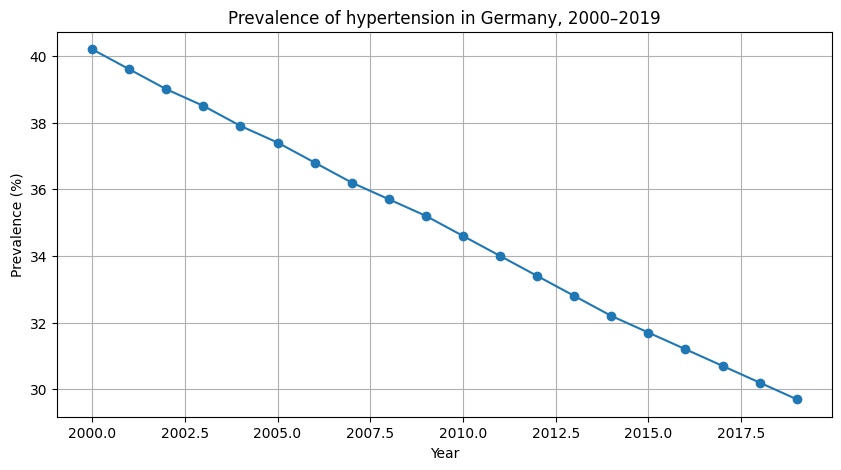

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(
    germany['Year'],
    germany['hypertension_prevalence'],
    marker='o'
)

plt.title('Prevalence of hypertension in Germany, 2000–2019')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.grid(True)
plt.show()

In [12]:
value_2000 = germany.loc[germany['Year'] == 2000, 'hypertension_prevalence'].iloc[0]
value_2019 = germany.loc[germany['Year'] == 2019, 'hypertension_prevalence'].iloc[0]

absolute_change = value_2019 - value_2000
relative_change = (absolute_change / value_2000) * 100

print(f"2000: {value_2000:.1f}%")
print(f"2019: {value_2019:.1f}%")
print(f"Absolute change: {absolute_change:.1f} percentage points")
print(f"Relative change: {relative_change:.1f}%")

2000: 40.2%
2019: 29.7%
Absolute change: -10.5 percentage points
Relative change: -26.1%


In [13]:
# Download gender analysis files
women = pd.read_csv('../data/raw/women-high-blood-pressure.csv')
men = pd.read_csv('../data/raw/men-high-blood-pressure.csv')

In [14]:
women.head()

,Entity,Code,Year,"Prevalence of hypertension in women aged 30–79 years, age-standardized"
0,Afghanistan,AFG,1990,37.7
1,Afghanistan,AFG,1991,37.7
2,Afghanistan,AFG,1992,37.8
3,Afghanistan,AFG,1993,37.8
4,Afghanistan,AFG,1994,37.9


In [15]:
women.columns

Index(['Entity', 'Code', 'Year',
       'Prevalence of hypertension in women aged 30–79 years, age-standardized'],
      dtype='object')

In [16]:
men.head()

,Entity,Code,Year,"Prevalence of hypertension in men aged 30–79 years, age-standardized"
0,Afghanistan,AFG,1990,33.2
1,Afghanistan,AFG,1991,33.3
2,Afghanistan,AFG,1992,33.4
3,Afghanistan,AFG,1993,33.5
4,Afghanistan,AFG,1994,33.6


In [17]:
men.columns

Index(['Entity', 'Code', 'Year',
       'Prevalence of hypertension in men aged 30–79 years, age-standardized'],
      dtype='object')

In [18]:
women = women.rename(columns={
    'Prevalence of hypertension in women aged 30–79 years, age-standardized': 'hypertension_women'
})

men = men.rename(columns={
    'Prevalence of hypertension in men aged 30–79 years, age-standardized': 'hypertension_men'
})

In [19]:
# Filter by Germany, 2000–2019
women_germany = women[
    (women['Entity'] == 'Germany') &
    (women['Year'] >= 2000) &
    (women['Year'] <= 2019)
].copy()

men_germany = men[
    (men['Entity'] == 'Germany') &
    (men['Year'] >= 2000) &
    (men['Year'] <= 2019)
].copy()

In [20]:
women_germany.shape, men_germany.shape

((20, 4), (20, 4))

In [21]:
women_germany = women_germany[['Entity', 'Code', 'Year', 'hypertension_women']]
men_germany = men_germany[['Entity', 'Code', 'Year', 'hypertension_men']]

In [22]:
# Merge women and men
gender_germany = pd.merge(
    women_germany,
    men_germany,
    on=['Entity', 'Code', 'Year'],
    how='inner'
)

In [23]:
gender_germany.head()

,Entity,Code,Year,hypertension_women,hypertension_men
0,Germany,DEU,2000,34.9,45.5
1,Germany,DEU,2001,34.3,44.9
2,Germany,DEU,2002,33.7,44.3
3,Germany,DEU,2003,33.1,43.8
4,Germany,DEU,2004,32.5,43.2


In [24]:
gender_germany.shape

(20, 5)

In [25]:
gender_germany['gender_gap_men_minus_women'] = (
    gender_germany['hypertension_men'] - gender_germany['hypertension_women']
)

In [26]:
gender_germany.head()

,Entity,Code,Year,hypertension_women,hypertension_men,gender_gap_men_minus_women
0,Germany,DEU,2000,34.9,45.5,10.6
1,Germany,DEU,2001,34.3,44.9,10.6
2,Germany,DEU,2002,33.7,44.3,10.6
3,Germany,DEU,2003,33.1,43.8,10.7
4,Germany,DEU,2004,32.5,43.2,10.7


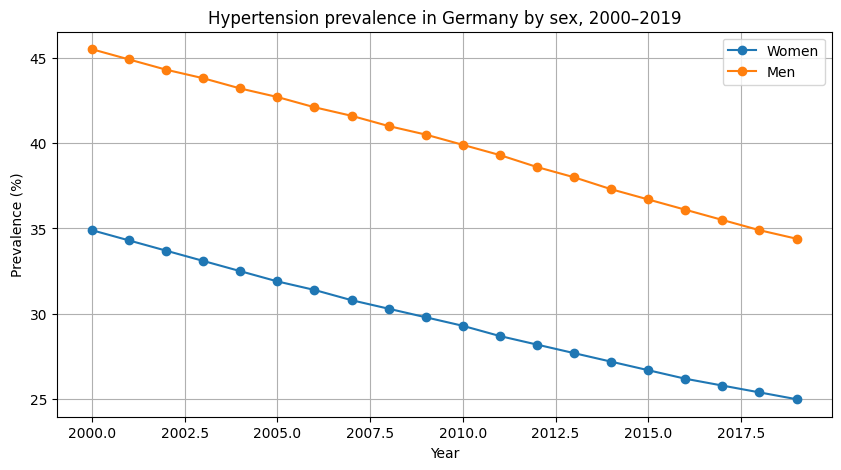

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    gender_germany['Year'],
    gender_germany['hypertension_women'],
    marker='o',
    label='Women'
)

plt.plot(
    gender_germany['Year'],
    gender_germany['hypertension_men'],
    marker='o',
    label='Men'
)

plt.title('Hypertension prevalence in Germany by sex, 2000–2019')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.show()

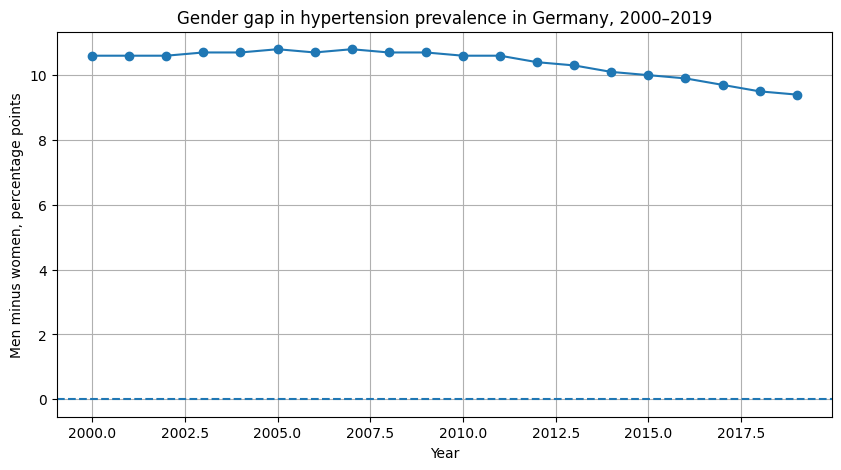

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    gender_germany['Year'],
    gender_germany['gender_gap_men_minus_women'],
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Gender gap in hypertension prevalence in Germany, 2000–2019')
plt.xlabel('Year')
plt.ylabel('Men minus women, percentage points')
plt.grid(True)
plt.show()

In [29]:
# Calculate the change for men and women
women_2000 = gender_germany.loc[
    gender_germany['Year'] == 2000, 'hypertension_women'
].iloc[0]

women_2019 = gender_germany.loc[
    gender_germany['Year'] == 2019, 'hypertension_women'
].iloc[0]

men_2000 = gender_germany.loc[
    gender_germany['Year'] == 2000, 'hypertension_men'
].iloc[0]

men_2019 = gender_germany.loc[
    gender_germany['Year'] == 2019, 'hypertension_men'
].iloc[0]

print(f"Women 2000: {women_2000:.1f}%")
print(f"Women 2019: {women_2019:.1f}%")
print(f"Women absolute change: {women_2019 - women_2000:.1f} percentage points")

print(f"Men 2000: {men_2000:.1f}%")
print(f"Men 2019: {men_2019:.1f}%")
print(f"Men absolute change: {men_2019 - men_2000:.1f} percentage points")

Women 2000: 34.9%
Women 2019: 25.0%
Women absolute change: -9.9 percentage points
Men 2000: 45.5%
Men 2019: 34.4%
Men absolute change: -11.1 percentage points


In [30]:
gender_germany.to_csv('../data/processed/germany_hypertension_by_sex_2000_2019.csv', index=False)

In [31]:
# Download the mortality file
mortality = pd.read_csv('../data/raw/death-rate-from-hypertensive-heart-disease-who-ghe-age-standardized.csv')

In [32]:
mortality.head()

,Entity,Code,Year,Age-standardized death rate from hypertensive heart disease among both sexes
0,Afghanistan,AFG,2000,88.98379
1,Afghanistan,AFG,2001,90.15682
2,Afghanistan,AFG,2002,91.47575
3,Afghanistan,AFG,2003,92.17575
4,Afghanistan,AFG,2004,92.29408


In [33]:
mortality.columns

Index(['Entity', 'Code', 'Year',
       'Age-standardized death rate from hypertensive heart disease among both sexes'],
      dtype='object')

In [34]:
mortality = mortality.rename(columns={
    'Age-standardized death rate from hypertensive heart disease among both sexes': 
    'hypertensive_heart_disease_death_rate'
})

In [35]:
# Filter by Germany, 2000–2019
mortality_germany = mortality[
    (mortality['Entity'] == 'Germany') &
    (mortality['Year'] >= 2000) &
    (mortality['Year'] <= 2019)
].copy()

In [36]:
mortality_germany.head()

,Entity,Code,Year,hypertensive_heart_disease_death_rate
1518,Germany,DEU,2000,7.579516
1519,Germany,DEU,2001,7.771165
1520,Germany,DEU,2002,8.414979
1521,Germany,DEU,2003,9.315402
1522,Germany,DEU,2004,9.446404


In [37]:
mortality_germany.shape

(20, 4)

In [38]:
mortality_germany = mortality_germany[
    ['Entity', 'Code', 'Year', 'hypertensive_heart_disease_death_rate']
]

In [39]:
# Check the passes and years
mortality_germany.isna().sum()

Entity                                   0
Code                                     0
Year                                     0
hypertensive_heart_disease_death_rate    0
dtype: int64

In [40]:
mortality_germany['Year'].min(), mortality_germany['Year'].max()

(np.int64(2000), np.int64(2019))

In [41]:
mortality_germany

,Entity,Code,Year,hypertensive_heart_disease_death_rate
1518,Germany,DEU,2000,7.579516
1519,Germany,DEU,2001,7.771165
1520,Germany,DEU,2002,8.414979
1521,Germany,DEU,2003,9.315402
1522,Germany,DEU,2004,9.446404
1523,Germany,DEU,2005,9.736816
1524,Germany,DEU,2006,9.697755
1525,Germany,DEU,2007,9.766206
1526,Germany,DEU,2008,9.787082
1527,Germany,DEU,2009,9.829870


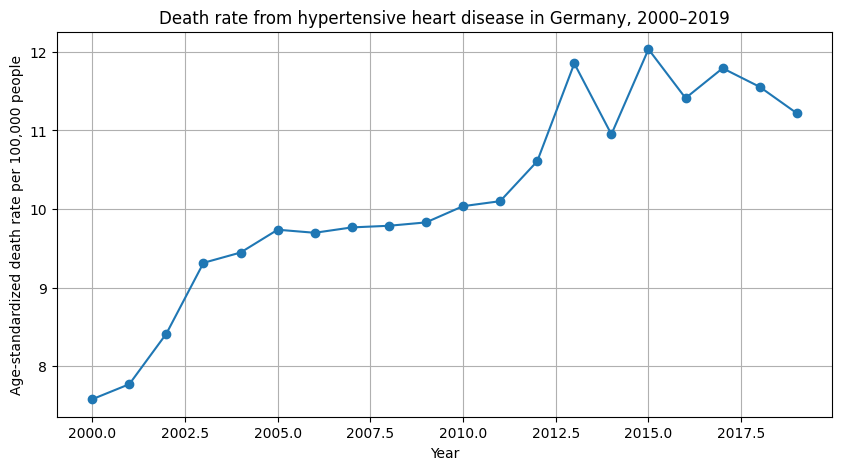

In [42]:
# Plot a mortality graph

plt.figure(figsize=(10, 5))

plt.plot(
    mortality_germany['Year'],
    mortality_germany['hypertensive_heart_disease_death_rate'],
    marker='o'
)

plt.title('Death rate from hypertensive heart disease in Germany, 2000–2019')
plt.xlabel('Year')
plt.ylabel('Age-standardized death rate per 100,000 people')
plt.grid(True)
plt.show()

In [43]:
# Calculate the change in mortality rates between 2000 and 2019

mortality_2000 = mortality_germany.loc[
    mortality_germany['Year'] == 2000,
    'hypertensive_heart_disease_death_rate'
].iloc[0]

mortality_2019 = mortality_germany.loc[
    mortality_germany['Year'] == 2019,
    'hypertensive_heart_disease_death_rate'
].iloc[0]

absolute_change_mortality = mortality_2019 - mortality_2000
relative_change_mortality = (absolute_change_mortality / mortality_2000) * 100

print(f"2000: {mortality_2000:.2f} deaths per 100,000")
print(f"2019: {mortality_2019:.2f} deaths per 100,000")
print(f"Absolute change: {absolute_change_mortality:.2f} deaths per 100,000")
print(f"Relative change: {relative_change_mortality:.1f}%")

2000: 7.58 deaths per 100,000
2019: 11.22 deaths per 100,000
Absolute change: 3.64 deaths per 100,000
Relative change: 48.0%


In [44]:
mortality_germany.to_csv(
    '../data/processed/germany_hypertensive_heart_disease_mortality_2000_2019.csv',
    index=False
)

In [45]:
# Merge prevalence and mortality data
public_health_germany = pd.merge(
    germany,
    mortality_germany,
    on=['Entity', 'Code', 'Year'],
    how='inner'
)

In [46]:
public_health_germany.head()

,Entity,Code,Year,hypertension_prevalence,hypertensive_heart_disease_death_rate
0,Germany,DEU,2000,40.2,7.579516
1,Germany,DEU,2001,39.6,7.771165
2,Germany,DEU,2002,39.0,8.414979
3,Germany,DEU,2003,38.5,9.315402
4,Germany,DEU,2004,37.9,9.446404


In [47]:
public_health_germany.shape

(20, 5)

In [48]:
public_health_germany.to_csv(
    '../data/processed/germany_hypertension_prevalence_and_mortality_2000_2019.csv',
    index=False
)

In [49]:
# Merge all data (gender, prevalence, mortality 2000-2019)
final_germany = pd.merge(
    public_health_germany,
    gender_germany,
    on=['Entity', 'Code', 'Year'],
    how='inner'
)

In [50]:
final_germany.head()

,Entity,Code,Year,hypertension_prevalence,hypertensive_heart_disease_death_rate,hypertension_women,hypertension_men,gender_gap_men_minus_women
0,Germany,DEU,2000,40.2,7.579516,34.9,45.5,10.6
1,Germany,DEU,2001,39.6,7.771165,34.3,44.9,10.6
2,Germany,DEU,2002,39.0,8.414979,33.7,44.3,10.6
3,Germany,DEU,2003,38.5,9.315402,33.1,43.8,10.7
4,Germany,DEU,2004,37.9,9.446404,32.5,43.2,10.7


In [51]:
final_germany.shape

(20, 8)

In [52]:
final_germany['Year'].min(), final_germany['Year'].max()

(np.int64(2000), np.int64(2019))

In [53]:
final_germany.isna().sum()

Entity                                   0
Code                                     0
Year                                     0
hypertension_prevalence                  0
hypertensive_heart_disease_death_rate    0
hypertension_women                       0
hypertension_men                         0
gender_gap_men_minus_women               0
dtype: int64

In [54]:
final_germany['Year'].nunique()

20

In [55]:
final_germany = final_germany[
    [
        'Entity',
        'Code',
        'Year',
        'hypertension_prevalence',
        'hypertension_women',
        'hypertension_men',
        'gender_gap_men_minus_women',
        'hypertensive_heart_disease_death_rate'
    ]
]

In [56]:
final_germany.duplicated(subset=['Entity', 'Year']).sum()

np.int64(0)

In [57]:
final_germany.to_csv(
    '../data/processed/germany_hypertension_public_health_2000_2019.csv',
    index=False
)

In [58]:
data_dictionary = {
    'Entity': 'Country name',
    'Code': 'Country ISO code',
    'Year': 'Year of observation',
    'hypertension_prevalence': 'Overall prevalence of hypertension among adults aged 30–79 (%)',
    'hypertension_women': 'Prevalence of hypertension among women aged 30–79, age-standardized (%)',
    'hypertension_men': 'Prevalence of hypertension among men aged 30–79, age-standardized (%)',
    'gender_gap_men_minus_women': 'Difference between men and women in percentage points',
    'hypertensive_heart_disease_death_rate': 'Age-standardized death rate from hypertensive heart disease per 100,000 people'
}

data_dictionary

{'Entity': 'Country name',
 'Code': 'Country ISO code',
 'Year': 'Year of observation',
 'hypertension_prevalence': 'Overall prevalence of hypertension among adults aged 30–79 (%)',
 'hypertension_women': 'Prevalence of hypertension among women aged 30–79, age-standardized (%)',
 'hypertension_men': 'Prevalence of hypertension among men aged 30–79, age-standardized (%)',
 'gender_gap_men_minus_women': 'Difference between men and women in percentage points',
 'hypertensive_heart_disease_death_rate': 'Age-standardized death rate from hypertensive heart disease per 100,000 people'}